# Figuras curadas para la tesis — narrativa nueva

Único notebook de figuras de la sección de diseño algorítmico: toma los datos
crudos de los experimentos y produce los archivos que se insertan en LaTeX.
**No es un notebook de exploración** — para eso están los notebooks de cada
fase. Acá cada figura es una decisión ya tomada.

Reemplaza a `figuras_tesis.ipynb`, que quedó atado a la corrida anterior del
procesador. El orden de la sección cambió y se simplificó:

1. **Ajuste de suavidad** — cuánta máscara se deja en la salida.
2. **Resultados del algoritmo** — el sistema, ya con la suavidad fijada, contra
   el resto de los procesadores.
3. **Geometría del arreglo** — pendiente: todavía no hay datos de la corrida
   nueva, así que no hay figuras acá.

Las figuras de robustez ante error de apuntamiento y desajuste del sensor
**salen** de la sección (estaban en `figuras_tesis.ipynb`, Figura 3).

**Criterios de diseño, comunes a todas las figuras:**

- **Tamaño.** Se generan al ancho exacto de la caja de texto de la tesis
  (`\textwidth` = 441,02 pt = 15,5 cm) y se insertan con `[width=\textwidth]`,
  de modo que el factor de escala sea 1,0 y los cuerpos tipográficos salgan del
  tamaño pedido (9 pt en ejes, 8 pt en marcas y leyenda) en lugar de estirarse o
  encogerse al importarlas.
- **Tipografía.** Sans humanista moderna (Inter), elegida sobre una serif tipo
  Times porque las etiquetas de esta sección son casi todas siglas en
  mayúsculas —`NM-MVDR`, `MVDR-geo`, `PESQ`, `STOI`— y en una serif salen
  desproporcionadas respecto del resto.
- **Paleta Okabe-Ito**, segura para daltonismo, con los **mismos colores por
  serie** que la versión anterior de las figuras: el color de cada serie se
  define **una sola vez** en `STYLE`.
- **Salida.** PDF vectorial (el que va en LaTeX) más PNG a 300 dpi para
  presentaciones, escritos directamente en el repositorio de la tesis.
- **Agregación por mediana** con banda intercuartílica, según el criterio del
  banco: SIR y SAR tienen colas largas que arrastran cualquier promedio.

**Nomenclatura.** Lo que en el código se llama `smooth` acá —y en el texto de la
tesis— se llama **suavidad de la máscara** ($s$). Es el mismo escalar: $s=1$ deja
la salida del beamformer sin post-filtrar y $s=0$ aplica la máscara completa.

**Orden de ejecución:** Configuración → Carga de datos → figuras (independientes
entre sí).

## Configuración compartida

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# --- Rutas -------------------------------------------------------------------
# Los datos viven junto a este notebook; las figuras se escriben DIRECTO en el
# repositorio de la tesis, para no tener que copiarlas a mano.
DATA_DIR = Path("../data").resolve()
FIG_DIR = Path("/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado").resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Geometria de la pagina --------------------------------------------------
# \textwidth del documento, en pulgadas (441,02 pt de TeX / 72,27). Las figuras
# se generan a ESTE ancho y se insertan con [width=\textwidth]: escala 1,0.
TEXTWIDTH_IN = 441.02 / 72.27

# --- Paleta Okabe-Ito --------------------------------------------------------
OKABE_ITO = {
    "negro":     "#000000",
    "naranja":   "#E69F00",
    "celeste":   "#56B4E9",
    "verde":     "#009E73",
    "amarillo":  "#F0E442",
    "azul":      "#0072B2",
    "bermellon": "#D55E00",
    "purpura":   "#CC79A7",
}

# Gris oscuro de los contornos (cajas, bigotes, medianas). No es negro puro:
# a 0,9 pt el negro pleno se ve duro contra los rellenos claros.
TRAZO = "#333333"


def tint(color, blanco=0.42):
    """Mezcla un color con blanco, devolviendo un tono pastel del mismo matiz.

    Se usa para el RELLENO de las cajas: contorno oscuro sobre relleno claro.
    Rellenar con el color pleno y dibujar la mediana en blanco hace que el
    boxplot se lea 'en negativo'. El 0,42 por defecto es un aclarado moderado:
    con mezclas mas altas el naranja del NM-MVDR viraba a crema y perdia la
    identidad de color que tiene en el resto de las figuras.
    """
    return tuple(c + (1.0 - c) * blanco for c in mpl.colors.to_rgb(color))


# --- Estilo por serie --------------------------------------------------------
# FUENTE UNICA DE VERDAD del color y el trazo de cada serie en toda la tesis.
# Se conservan los colores de la version anterior de las figuras: NM-MVDR sigue
# siendo naranja, MVDR-geo bermellon, DS verde, DTLN-mono purpura.
#   Entrada / DTLN-mono son REFERENCIAS (no filtran espacialmente) -> trazo
#   discontinuo, para que se distingan de los procesadores de un vistazo.
STYLE = {
    "Entrada":   dict(color=OKABE_ITO["negro"],     ls=":",  marker="o"),
    "DTLN-mono": dict(color=OKABE_ITO["purpura"],   ls="-.", marker="v"),
    "DS":        dict(color=OKABE_ITO["verde"],     ls="-",  marker="^"),
    "MVDR-geo":  dict(color=OKABE_ITO["bermellon"], ls="-",  marker="s"),
    "NM-MVDR":   dict(color=OKABE_ITO["naranja"],   ls="-",  marker="o"),
}

# --- Series de la comparacion de algoritmos ----------------------------------
# (nombre, prefijo de columna, procesador a filtrar)
#   'base'       -> senal del microfono de referencia, sin procesar
#   'dtln_alone' -> DTLN monoaural sobre ese mismo canal
#   'proc'       -> salida del procesador indicado
# Entrada y DTLN-mono NO dependen del procesador: se leen del cuadro de escenas
# unicas, porque cada escena aparece repetida una vez por beamformer corrido.
# El ORDEN de esta lista es el orden de las cajas y de la leyenda: de menor a
# mayor desempeno esperado, con la Entrada a la izquierda como punto de partida.
SERIES = [
    ("Entrada",   "base",       None),
    ("DS",        "proc",       "DS"),
    ("MVDR-geo",  "proc",       "MVDR-geo"),
    ("DTLN-mono", "dtln_alone", None),
    ("NM-MVDR",   "proc",       "NM-MVDR"),
]

# Etiquetas cortas para los ejes CATEGORICOS. En el boxplot las cinco series
# comparten un ancho de medio \textwidth, donde los nombres completos no entran
# horizontales y hay que girarlos; girados dejan de estar centrados bajo su caja
# y se leen peor que el nombre abreviado. El nombre completo sigue estando en la
# leyenda de las figuras de curvas, en la tabla y en el texto.
#   MVDR-geo -> "MVDR": en esta figura el otro MVDR se escribe entero
#               ("NM-MVDR"), asi que no hay ambiguedad posible.
#   DTLN-mono -> "DTLN": es la unica variante de DTLN que aparece en la figura.
SHORT = {"Entrada": "Entrada", "DS": "DS", "MVDR-geo": "MVDR",
         "DTLN-mono": "DTLN", "NM-MVDR": "NM-MVDR"}

# Claves que identifican una escena fisica (sin el procesador).
SCENE_KEYS = ["source", "rt60", "isir_db", "target_angle", "target_dist",
              "N_interferences"]

METRIC_LABEL = {
    "PESQ": "PESQ", "STOI": "STOI", "SI-SDR": "SI-SDR [dB]",
    "SDR": "SDR [dB]", "SIR": "SIR [dB]", "SAR": "SAR [dB]",
}
DELTA_LABEL = {
    "PESQ": "Δ PESQ", "STOI": "Δ STOI", "SI-SDR": "Δ SI-SDR [dB]",
    "SDR": "Δ SDR [dB]", "SIR": "Δ SIR [dB]", "SAR": "Δ SAR [dB]",
}

# --- Rango vertical de las metricas acotadas ---------------------------------
# Se aplica SOLO a la figura de resultados absolutos, que es la que fija la
# lectura absoluta de la seccion; las figuras de tendencia comparan curvas entre
# si y ahi el rango lo fijan los datos.
#   STOI -> escala completa [0, 1]. Es acotada y mostrarla entera cuesta poca
#           resolucion frente a lo que aporta como referencia.
#   PESQ -> se ancla el PISO en 1,0, que es el minimo real de la metrica y donde
#           efectivamente esta la senal de entrada. El techo NO se lleva a 4,5:
#           ese valor corresponde a habla practicamente limpia, inalcanzable en
#           este escenario, y dejarlo dentro comprimiria toda la comparacion en
#           el tercio inferior del eje.
METRIC_LIMS = {"PESQ": (1.0, None), "STOI": (0.0, 1.0)}

# --- Estilo de matplotlib ----------------------------------------------------
# Sans humanista moderna. Inter tiene mayusculas de proporcion contenida, que es
# lo que necesitan los nombres de los algoritmos (NM-MVDR, MVDR-geo) y las
# metricas (PESQ, STOI): en una serif tipo Times esas siglas salen
# desproporcionadas.
_SANS = ["Inter", "Lato", "Roboto", "Open Sans", "Liberation Sans", "DejaVu Sans"]
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": _SANS,
    # mathtext en la MISMA familia, para que $RT_{60}$ no cambie de tipografia
    # respecto del resto de la etiqueta.
    "mathtext.fontset": "custom",
    "mathtext.rm": _SANS[0],
    "mathtext.it": f"{_SANS[0]}:italic",
    "mathtext.bf": f"{_SANS[0]}:bold",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.edgecolor": TRAZO,
    "axes.labelcolor": TRAZO,
    "text.color": TRAZO,
    "xtick.color": TRAZO,
    "ytick.color": TRAZO,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.35,
    "lines.linewidth": 1.1,
    "lines.markersize": 3.3,
    "figure.dpi": 120,
    # bbox 'standard' (NO 'tight'): recortar el borde cambiaria el ancho del PDF
    # y LaTeX lo re-escalaria, alterando el tamano real de la tipografia.
    "savefig.bbox": "standard",
    "pdf.fonttype": 42,   # TrueType embebido; evita Type 3
    "ps.fonttype": 42,
})


def save_fig(fig, name, png=True):
    """Escribe la figura en el repositorio de la tesis: PDF (LaTeX) y PNG (slides)."""
    salidas = [FIG_DIR / f"{name}.pdf"]
    fig.savefig(salidas[0])
    if png:
        salidas.append(FIG_DIR / f"{name}.png")
        fig.savefig(salidas[1], dpi=300)
    w, h = fig.get_size_inches()
    print(f"[ok] {name}  {w * 2.54:.1f} x {h * 2.54:.1f} cm  ->  "
          f"{', '.join(p.name for p in salidas)}")
    return salidas


def col(prefix, metric):
    """Nombre de columna de una metrica. Todo se mide contra la referencia
    temprana, de ahi el sufijo `_early`."""
    return f"{prefix}_{metric}_early"


def filas(df, escenas, proc):
    """Filas sobre las que se lee una serie: el cuadro de escenas unicas si la
    serie no depende del procesador, o las filas de ese procesador si depende."""
    return escenas if proc is None else df[df["processor"] == proc]


def num(v, dec=2):
    """Numero con coma decimal (convencion del documento), sin usar locale."""
    return f"{v:.{dec}f}".replace(".", ",")

## Carga de datos

Dos corridas del banco, ninguna de las dos con la cascada `+DTLN-post` (esa rama
quedó descartada del sistema):

| corrida | qué barre | para qué |
|---|---|---|
| `F1_postfiltro_*` | suavidad $s \in \{0;\,0{,}2;\,\dots;\,1\}$ × $RT_{60}$ × iSIR × layout × locutor | elegir $s^\star$ |
| `P1_diversidad` | $RT_{60}$ × DOA × distancia × layout × iSIR × locutor, para DS / MVDR-geo / NM-MVDR | comparar algoritmos |

El baseline monocanal (`DTLN-mono`) no es un procesador de la grilla: sale
automáticamente del motor en las columnas `dtln_alone_*` de `P1_diversidad`, una
vez por escena.

> ⚠️ **Las dos corridas no están sincronizadas.** `P1_diversidad` se lanzó
> (14:31) *antes* de que la Fase 1 terminara de escribir su
> `smooth_decision.json` (15:54), así que tomó el de una corrida anterior y
> corrió el NM-MVDR con **suavidad 0,0**, no con el $s^\\star = 0{,}2$ que la
> Fase 1 efectivamente eligió. La celda de carga lo verifica y avisa. Las
> figuras de la comparación de algoritmos son válidas como comparación —los tres
> procesadores recorren las mismas escenas— pero el NM-MVDR aparece en un punto
> de operación peor que el del sistema final: según la Figura 1, $s=0$ deja
> ≈ 0,30 de $\\Delta$ PESQ sobre la mesa respecto de $s^\\star$. **Hay que volver a
> correr P1 con $s^\\star = 0{,}2$ y regenerar estas tres figuras.**

In [2]:
import re

# --- Fase 1: barrido de suavidad --------------------------------------------
# Se toma la corrida MAS RECIENTE de F1_postfiltro_*; fijar F1_DIR a mano para
# analizar una corrida vieja.
F1_DIR = sorted(DATA_DIR.glob("F1_postfiltro_*"))[-1]

# --- Fase 2: comparacion contra los otros algoritmos -------------------------
P1_DIR = DATA_DIR / "P1_diversidad"


def load_exp(d):
    """Carga un experimento del banco.

    Los `inf` de SIR/SAR se convierten a NaN una sola vez, aca: son valores
    reales (escenas donde la interferencia residual se anula exactamente) pero
    rompen cualquier agregado, asi que se los descarta en el origen.
    """
    parquet = d / "mird_benchmark_metrics.parquet"
    df = pd.read_parquet(parquet) if parquet.exists() \
        else pd.read_csv(d / "mird_benchmark_metrics.csv")
    return df.replace([np.inf, -np.inf], np.nan)


# El barrido de suavidad viene codificado en el nombre del procesador
# (`NM-MVDR_s0.20`): se lo pasa a columna numerica una sola vez.
df_S = load_exp(F1_DIR)
df_S["suavidad"] = df_S["processor"].str.extract(r"_s([0-9.]+)$").astype(float)
SUAVIDADES = sorted(df_S["suavidad"].unique())

# Punto elegido por la regla de decision de la Fase 1 (queda escrito en
# smooth_decision.json junto a los datos): se lee del JSON y no se escribe a
# mano, para que la linea vertical de la figura no pueda desincronizarse.
import json
S_STAR = float(json.loads((F1_DIR / "smooth_decision.json").read_text())["smooth_fijo"])

df_P1 = load_exp(P1_DIR)
# Una fila por escena fisica: las de P1 vienen repetidas una vez por procesador.
escenas_P1 = df_P1.drop_duplicates(subset=SCENE_KEYS)

ISIRS = sorted(df_P1["isir_db"].unique())
RT60S = sorted(df_P1["rt60"].unique())

print(f"Suavidad ({F1_DIR.name})")
print(f"  {len(df_S):5d} filas | {len(df_S) // len(SUAVIDADES)} escenas x "
      f"{len(SUAVIDADES)} valores de suavidad {SUAVIDADES} | s* = {S_STAR}")
print(f"Algoritmos ({P1_DIR.name})")
print(f"  {len(df_P1):5d} filas | {len(escenas_P1)} escenas | "
      f"procesadores: {', '.join(sorted(df_P1.processor.unique()))}")

faltan = [p for _, _, p in SERIES if p and p not in set(df_P1.processor)]
assert not faltan, f"Faltan procesadores en P1: {faltan}"

# --- Coherencia entre las dos corridas ---------------------------------------
# La Fase 2 toma su smooth del smooth_decision.json MAS RECIENTE que encuentra.
# Si se la lanzo antes de que la Fase 1 terminara de escribir el suyo, se queda
# con el de una corrida vieja y la comparacion de algoritmos NO corre con el s*
# que decidio la Fase 1. Vale la pena que salte aca y no en la lectura del
# capitulo: la figura sigue dibujandose, pero el numero de NM-MVDR es el de otro
# punto de operacion.
S_P1 = float(json.loads((P1_DIR / "DONE.json").read_text())["smooth_star"])
if S_P1 != S_STAR:
    print(f"\n[!] La corrida de algoritmos uso suavidad {S_P1}, no el "
          f"s* = {S_STAR} que eligio la Fase 1.\n"
          f"    Las figuras F2_* muestran el NM-MVDR en un punto de operacion "
          f"distinto del que fija la tesis: hay que volver a correr P1.")
else:
    print(f"\n[ok] Ambas corridas coinciden en s* = {S_STAR}.")

Suavidad (F1_postfiltro_20260907_142125)
    288 filas | 48 escenas x 6 valores de suavidad [np.float64(0.0), np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0)] | s* = 0.2
Algoritmos (P1_diversidad)
   1296 filas | 432 escenas | procesadores: DS, MVDR-geo, NM-MVDR

[!] La corrida de algoritmos uso suavidad 0.0, no el s* = 0.2 que eligio la Fase 1.
    Las figuras F2_* muestran el NM-MVDR en un punto de operacion distinto del que fija la tesis: hay que volver a correr P1.


## Figura 1 — Ajuste de la suavidad de la máscara

Mejora end-to-end de PESQ y STOI contra la suavidad $s$ del post-filtro, sobre
las 48 escenas del barrido. La curva gruesa naranja es la mediana global —la que
decide— con su banda intercuartílica; las curvas finas azules son la misma
mediana partida por iSIR, de claro (iSIR bajo) a oscuro (iSIR alto).

Se grafica la **mejora** ($\Delta$ respecto de la señal del micrófono de
referencia) y no el valor absoluto: la suavidad no toca el filtro espacial —sólo
la ganancia real que se aplica al final— así que lo único que se está midiendo
acá es cuánto suma o resta el post-filtro, y en $\Delta$ las cuatro curvas de
iSIR quedan comparables entre sí pese a partir de pisos muy distintos.

**La lectura.** PESQ tiene un máximo claro en $s^\star = 0{,}2$ y cae hacia los
dos extremos: sin post-filtro ($s=1$) se deja mejora sobre la mesa, y con la
máscara completa ($s=0$) la distorsión que introduce el enmascarado ya pesa más
que la interferencia que saca. STOI, en cambio, es prácticamente plano de $0{,}2$
a $1$ — la inteligibilidad no se paga en ese tramo, que es lo que habilita a
elegir el $s$ por PESQ.

**Por qué un valor fijo y no una agenda.** Las cuatro curvas de iSIR tienen el
máximo en el mismo lugar (salvo la de $+10$ dB, que lo corre a $0{,}4$ por un
margen chico): la posición del óptimo no depende del iSIR, así que no hay nada
que ganar programando la suavidad en línea. El $s^\star$ y la línea vertical
punteada se leen de `smooth_decision.json`, no se escriben a mano.

[ok] F1_suavidad  15.5 x 7.4 cm  ->  F1_suavidad.pdf, F1_suavidad.png


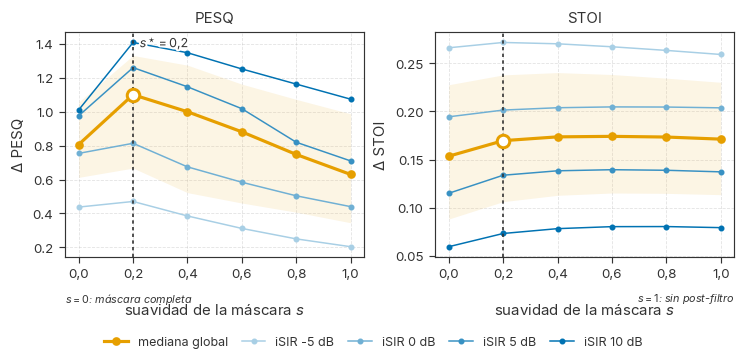

In [3]:
import matplotlib.patheffects as pe

METRICS_SUAV = ["PESQ", "STOI"]

# Rampa secuencial de un solo matiz para el iSIR. El iSIR es una variable
# ORDINAL: se codifica con claro->oscuro sobre el azul Okabe-Ito y no con cuatro
# colores distintos, que competirian con la identidad de serie del resto de las
# figuras. La curva global va en el naranja del NM-MVDR, que es de quien se esta
# eligiendo la suavidad.
RAMPA_ISIR = {v: tint(OKABE_ITO["azul"], b)
              for v, b in zip(ISIRS, np.linspace(0.66, 0.0, len(ISIRS)))}
C_GLOBAL = STYLE["NM-MVDR"]["color"]

fig, axes = plt.subplots(1, len(METRICS_SUAV), figsize=(TEXTWIDTH_IN, 2.9),
                         layout="constrained")

for ax, metric in zip(axes, METRICS_SUAV):
    c = col("Delta_tot", metric)

    # Curvas por iSIR: dicen si el optimo se MUEVE con la relacion senal a
    # interferencia (y por lo tanto si haria falta agendar la suavidad en linea).
    for isir in ISIRS:
        g = df_S[df_S.isir_db == isir].groupby("suavidad")[c].median()
        ax.plot(g.index.values, g.values, color=RAMPA_ISIR[isir], lw=0.9,
                marker="o", ms=2.6, label=f"{isir:d} dB", zorder=2)

    # Curva global (mediana sobre las 48 escenas) con banda intercuartilica:
    # es la curva sobre la que se toma la decision.
    g = df_S.groupby("suavidad")[c]
    med, p25, p75 = g.median(), g.quantile(0.25), g.quantile(0.75)
    x = med.index.values
    ax.fill_between(x, p25.values, p75.values, color=tint(C_GLOBAL, 0.35),
                    alpha=0.16, lw=0, zorder=1)
    ax.plot(x, med.values, color=C_GLOBAL, lw=1.9, marker="o", ms=4.2,
            label="mediana global", zorder=4)

    # Punto elegido: linea vertical punteada + marcador resaltado sobre la curva.
    ax.axvline(S_STAR, color=TRAZO, ls=(0, (2, 2)), lw=1.0, zorder=3)
    ax.plot([S_STAR], [med.loc[S_STAR]], marker="o", ms=7.5, mfc="white",
            mec=C_GLOBAL, mew=1.8, zorder=5)

    ax.set_xticks(SUAVIDADES)
    ax.set_xticklabels([num(s, 1) for s in SUAVIDADES])
    ax.set_xlabel("suavidad de la máscara $s$", labelpad=13)
    ax.set_ylabel(DELTA_LABEL[metric])
    ax.set_title(metric)
    ax.grid(True)
    ax.set_axisbelow(True)

# Etiqueta del punto elegido, una sola vez y sobre el panel izquierdo.
axes[0].annotate("$s^\\star = " + num(S_STAR, 1).replace(",", "{,}") + "$",
                 xy=(S_STAR, 1.0),
                 xycoords=("data", "axes fraction"), xytext=(4, -9),
                 textcoords="offset points", fontsize=7.5, color=TRAZO,
                 fontweight="semibold",
                 path_effects=[pe.withStroke(linewidth=2.4, foreground="white")])

# Los extremos del eje no son obvios y no entran en la etiqueta sin alargarla.
# Se reparten entre los dos paneles -que comparten el mismo eje x- para que
# juntos lo anoten de punta a punta en lugar de amontonarse debajo de uno solo.
axes[0].text(0.0, -0.155, "$s=0$: máscara completa", transform=axes[0].transAxes,
             ha="left", va="top", fontsize=6.5, color=TRAZO, style="italic")
axes[-1].text(1.0, -0.155, "$s=1$: sin post-filtro", transform=axes[-1].transAxes,
              ha="right", va="top", fontsize=6.5, color=TRAZO, style="italic")

handles = [Line2D([0], [0], color=C_GLOBAL, lw=1.9, marker="o", ms=4.2,
                  label="mediana global")]
handles += [Line2D([0], [0], color=RAMPA_ISIR[v], lw=0.9, marker="o", ms=2.6,
                   label=f"iSIR {v:d} dB") for v in ISIRS]
fig.legend(handles=handles, loc="outside lower center", ncol=len(handles),
           frameon=False, handlelength=1.9, columnspacing=1.1, fontsize=7.5)

save_fig(fig, "F1_suavidad")
plt.show()

## Figura 2 — Resultados absolutos sobre el envolvente de diversidad acústica

Distribución de cada métrica en valores absolutos sobre las 432 escenas de
`P1_diversidad` (2 locutores × 3 $RT_{60}$ × 3 ángulos de target × 2 distancias ×
3 cantidades de interferentes × 4 iSIR), una caja por serie.

Las series van ordenadas de menor a mayor desempeño esperado, con la Entrada a la
izquierda como punto de partida y el NM-MVDR a la derecha. La línea punteada es
la mediana de la Entrada: **la distancia de cada caja a esa línea es la mejora**,
que es lo que permite mostrar valores absolutos sin perder la lectura de cuánto
aporta cada procesador.

**Escala vertical.** Esta es la figura que fija la lectura absoluta de la
sección, así que las métricas acotadas se muestran contra su escala real y no
contra el rango de los datos: STOI va completa, de 0 a 1, y PESQ arranca en 1,0,
que es su mínimo posible y donde efectivamente está la señal de entrada. El techo
de PESQ (4,5) queda fuera a propósito: corresponde a habla prácticamente limpia,
inalcanzable en estas condiciones, y meterlo en el eje comprimiría toda la
comparación en el tercio inferior. Se cambia en `METRIC_LIMS`.

**El ancho de las cajas importa tanto como su posición.** SIR y SDR muestran la
diferencia estructural: los geométricos tienen cajas anchas —dependen de que el
apuntado y la escena los acompañen— mientras que el NM-MVDR se concentra en un
rango angosto y alto, que es lo que se le pide a un sistema que va a correr sin
supervisión.

[ok] F2_boxplot  15.5 x 12.4 cm  ->  F2_boxplot.pdf, F2_boxplot.png


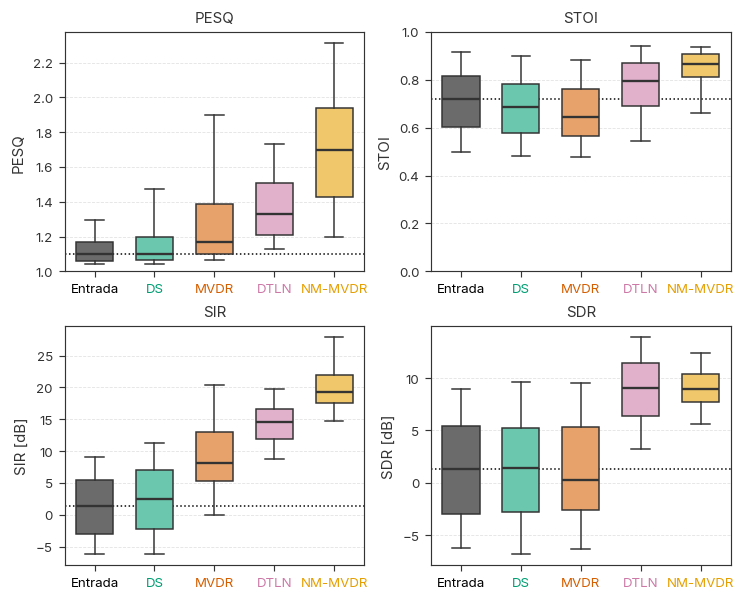

In [4]:
METRICS_BOX = ["PESQ", "STOI", "SIR", "SDR"]

fig, axes = plt.subplots(2, 2, figsize=(TEXTWIDTH_IN, 4.9), layout="constrained")

for ax, metric in zip(axes.ravel(), METRICS_BOX):
    datos, colores = [], []
    for nombre, prefijo, proc in SERIES:
        src = filas(df_P1, escenas_P1, proc)
        datos.append(src[col(prefijo, metric)].dropna().values)
        colores.append(STYLE[nombre]["color"])

    # Contorno oscuro sobre relleno pastel: es lo que hace legible la caja.
    # Bigotes a P5-P95 y SIN atipicos individuales: con cientos de escenas por
    # serie, los circulos de atipicos por default (>1,5 RIC) se acumulan en una
    # nube que ensucia la figura sin agregar informacion nueva.
    bp = ax.boxplot(
        datos, positions=np.arange(len(datos)), widths=0.62, patch_artist=True,
        whis=(5, 95), showfliers=False,
        boxprops=dict(lw=0.9, edgecolor=TRAZO),
        medianprops=dict(color=TRAZO, lw=1.4),
        whiskerprops=dict(color=TRAZO, lw=0.9),
        capprops=dict(color=TRAZO, lw=0.9),
    )
    for caja, c in zip(bp["boxes"], colores):
        caja.set_facecolor(tint(c))

    # Mediana de la Entrada: referencia visual de cuanta mejora aporta cada caja.
    ax.axhline(np.nanmedian(datos[0]), color=STYLE["Entrada"]["color"],
               ls=":", lw=0.9, zorder=0)

    # Metricas acotadas: se muestra la escala completa (STOI) o al menos el piso
    # real de la metrica (PESQ). Ver METRIC_LIMS en la celda de configuracion.
    lo, hi = METRIC_LIMS.get(metric, (None, None))
    ax.set_ylim(bottom=lo, top=hi)

    ax.set_ylabel(METRIC_LABEL[metric])
    ax.set_title(metric)
    ax.set_xticks(np.arange(len(SERIES)))
    # Horizontales y centradas bajo su caja: con las etiquetas cortas de SHORT
    # entran sin girar, y sin giro no hace falta anclarlas por la derecha (que
    # es lo que las descentraba respecto de la caja).
    ax.set_xticklabels([SHORT[s[0]] for s in SERIES])
    for lbl, (nombre, _, _) in zip(ax.get_xticklabels(), SERIES):
        lbl.set_color(STYLE[nombre]["color"])
    ax.grid(axis="y")
    ax.set_axisbelow(True)

save_fig(fig, "F2_boxplot")
plt.show()

## Figura 3 — Tendencias contra el iSIR

Mediana de cada métrica contra el iSIR de entrada, con la banda intercuartílica
(P25–P75) entre escenas detrás de cada curva de procesador. Entrada y DTLN-mono
van sin banda, para no saturar la figura.

El iSIR es el eje que ordena la dificultad de la escena: barre de $-5$ dB
(interferencia más fuerte que el target) a $+10$ dB. Es el corte que dice si la
ventaja del sistema es un promedio favorable o se sostiene en todo el rango — y
en particular si aguanta el extremo difícil, que es donde los geométricos se
quedan sin margen.

[ok] F2_curvas_isir  15.5 x 10.9 cm  ->  F2_curvas_isir.pdf, F2_curvas_isir.png


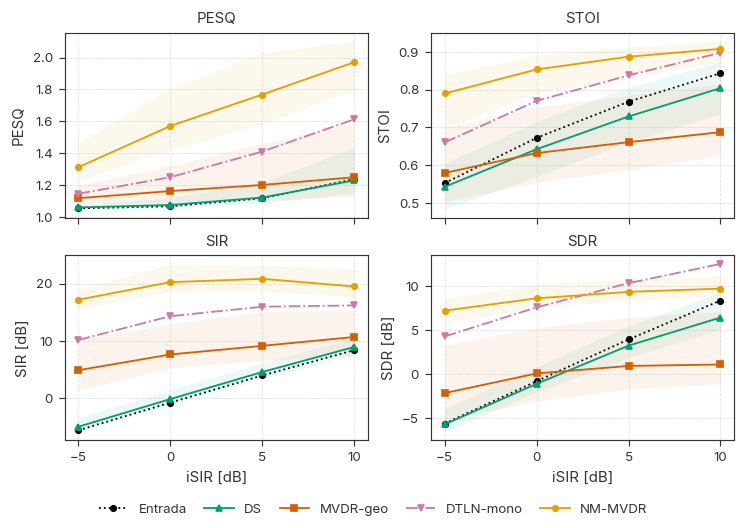

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(TEXTWIDTH_IN, 4.3), sharex=True,
                         layout="constrained")

for ax, metric in zip(axes.ravel(), METRICS_BOX):
    for nombre, prefijo, proc in SERIES:
        src = filas(df_P1, escenas_P1, proc)
        g = src.groupby("isir_db")[col(prefijo, metric)]
        med = g.median().sort_index()
        st = STYLE[nombre]
        if proc is not None:   # banda RIC solo para los procesadores
            p25 = g.quantile(0.25).reindex(med.index).values
            p75 = g.quantile(0.75).reindex(med.index).values
            ax.fill_between(med.index.values, p25, p75,
                            color=tint(st["color"], 0.35), alpha=0.11, lw=0)
        ax.plot(med.index.values, med.values, color=st["color"], ls=st["ls"],
                marker=st["marker"], label=nombre)

    ax.set_xticks(ISIRS)
    ax.set_ylabel(METRIC_LABEL[metric])
    ax.set_title(metric)
    ax.grid(True)
    ax.set_axisbelow(True)

for ax in axes[-1]:
    ax.set_xlabel("iSIR [dB]")

handles = [Line2D([0], [0], color=STYLE[n]["color"], ls=STYLE[n]["ls"],
                  marker=STYLE[n]["marker"], label=n) for n, _, _ in SERIES]
fig.legend(handles=handles, loc="outside lower center", ncol=len(SERIES),
           frameon=False, handlelength=2.2, columnspacing=1.3)

save_fig(fig, "F2_curvas_isir")
plt.show()

## Figura 4 — Mapa de operación del NM-MVDR ($RT_{60}$ × iSIR)

Sólo el sistema elegido, sobre las dos métricas perceptuales, en las 12 celdas de
la grilla $RT_{60}$ × iSIR (36 escenas por celda). El color codifica la **mejora
mediana** que aporta el sistema; el número chico debajo, el **valor absoluto**
que alcanza ahí.

Las dos lecturas no coinciden, y por eso están las dos: la mejora de STOI es
máxima donde la entrada está peor (iSIR $-5$ dB) y se achica hacia la derecha
simplemente porque ya no queda inteligibilidad para recuperar, mientras que el
valor absoluto sube de forma monótona con el iSIR. En PESQ pasa lo contrario: la
mejora crece con el iSIR, porque el post-filtro tiene más señal limpia sobre la
cual trabajar.

Los paneles son **cuadrados por construcción** (`set_box_aspect(1)`), con
independencia de que la grilla sea de 3×4: así los dos mapas se leen como un par
y no como dos rectángulos de proporciones distintas.

El colormap es un degradado construido sobre el naranja del NM-MVDR: en esta
figura hay un solo procesador, así que el color codifica magnitud y no identidad
de serie, y conviene que herede el matiz del sistema en lugar de traer un
colormap ajeno a la paleta.

[ok] F2_heatmap_rt_isir  15.5 x 7.1 cm  ->  F2_heatmap_rt_isir.pdf, F2_heatmap_rt_isir.png


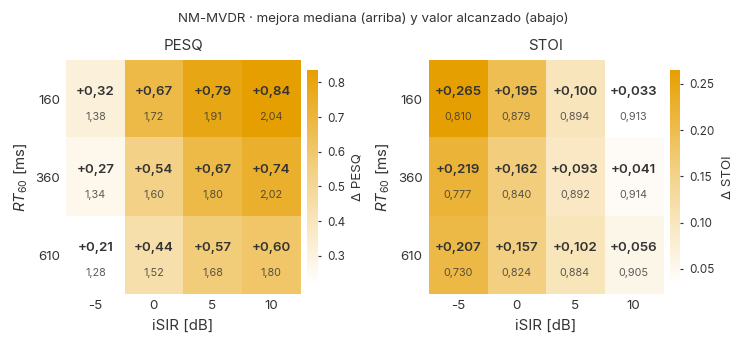

In [6]:
METRICS_HEAT = ["PESQ", "STOI"]
NDEC_HEAT = {"PESQ": 2, "STOI": 3}

# Mapa secuencial construido sobre el naranja del NM-MVDR: la figura habla de un
# solo procesador, asi que el color codifica magnitud y no identidad de serie, y
# hereda el matiz del sistema en lugar de traer un colormap ajeno a la paleta.
# El extremo saturado se queda EN el naranja Okabe-Ito y no sigue hacia un ocre
# oscuro: asi ninguna celda necesita texto blanco y las 24 anotaciones van todas
# en el mismo gris, que es lo que hace legible la figura de un vistazo.
CMAP_NM = LinearSegmentedColormap.from_list(
    "nm_mvdr", ["#FFFFFF", tint(STYLE["NM-MVDR"]["color"], 0.55),
                STYLE["NM-MVDR"]["color"]])

nm = df_P1[df_P1.processor == "NM-MVDR"]

fig, axes = plt.subplots(1, len(METRICS_HEAT), figsize=(TEXTWIDTH_IN, 2.8),
                         layout="constrained")

for ax, metric in zip(axes, METRICS_HEAT):
    # Color = MEJORA que aporta el sistema en cada celda de la grilla; el numero
    # chico debajo es el valor ABSOLUTO alcanzado ahi. Las dos lecturas conviven
    # en la misma celda: donde mas gana no es donde mejor termina.
    d_piv = nm.pivot_table(index="rt60", columns="isir_db",
                           values=col("Delta_tot", metric), aggfunc="median")
    a_piv = nm.pivot_table(index="rt60", columns="isir_db",
                           values=col("proc", metric), aggfunc="median")
    d_piv, a_piv = d_piv.reindex(RT60S)[ISIRS], a_piv.reindex(RT60S)[ISIRS]

    im = ax.imshow(d_piv.values, cmap=CMAP_NM, aspect="auto", origin="upper")
    ax.set_box_aspect(1)   # panel cuadrado, con independencia de la grilla 3x4

    for i in range(d_piv.shape[0]):
        for j in range(d_piv.shape[1]):
            ax.text(j, i - 0.10, f"+{num(d_piv.values[i, j], NDEC_HEAT[metric])}",
                    ha="center", va="center", fontsize=8, fontweight="semibold",
                    color=TRAZO)
            ax.text(j, i + 0.22, num(a_piv.values[i, j], NDEC_HEAT[metric]),
                    ha="center", va="center", fontsize=6.5, color=TRAZO, alpha=0.8)

    ax.set_xticks(range(len(ISIRS)), [f"{v:d}" for v in ISIRS])
    ax.set_yticks(range(len(RT60S)), [f"{int(round(r * 1000))}" for r in RT60S])
    ax.set_xlabel("iSIR [dB]")
    ax.set_ylabel(r"$RT_{60}$ [ms]")
    ax.set_title(metric)
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(length=0)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label(DELTA_LABEL[metric], fontsize=8)
    cb.outline.set_visible(False)
    cb.ax.tick_params(labelsize=7, length=2, width=0.7)

# Clave de lectura de la celda: sin esto los dos numeros apilados son ambiguos.
fig.suptitle("NM-MVDR · mejora mediana (arriba) y valor alcanzado (abajo)",
             fontsize=8, color=TRAZO)

save_fig(fig, "F2_heatmap_rt_isir")
plt.show()

## Tablas — filas listas para pegar en LaTeX

Mediana por serie y por métrica sobre las escenas de `P1_diversidad`, con la
mejor de cada columna marcada con `\best`, más el barrido de suavidad de la
Figura 1 en forma de tabla.

In [7]:
METRICS_TAB = ["PESQ", "STOI", "SIR", "SDR"]
NDEC_TAB = {"PESQ": 3, "STOI": 3, "SIR": 1, "SDR": 1}

# Mediana por serie: las cuatro metricas son "mayor es mejor", asi que la mejor
# de cada columna sale del maximo y se marca con \best para la tabla del texto.
tab = pd.DataFrame({
    nombre: {m: filas(df_P1, escenas_P1, proc)[col(prefijo, m)].median()
             for m in METRICS_TAB}
    for nombre, prefijo, proc in SERIES
}).T
mejor = {m: tab[m].idxmax() for m in METRICS_TAB}

print(r"% mediana sobre las {} escenas de P1; negrita = mejor de la columna".format(len(escenas_P1)))
for nombre, _, _ in SERIES:
    celdas = []
    for m in METRICS_TAB:
        v = num(tab.loc[nombre, m], NDEC_TAB[m])
        celdas.append(f"\\best{{{v}}}" if mejor[m] == nombre else v)
    print(f"{nombre} & {' & '.join(celdas)} \\\\")

print()
print(f"% barrido de suavidad (mediana sobre {len(df_S) // len(SUAVIDADES)} escenas)")
med_s = df_S.groupby("suavidad")[[col("Delta_tot", m) for m in ["PESQ", "STOI"]]].median()
for s in SUAVIDADES:
    marca = r"  <- s*" if s == S_STAR else ""
    print(f"s = {num(s, 1)} & {num(med_s.loc[s, col('Delta_tot', 'PESQ')], 3)} & "
          f"{num(med_s.loc[s, col('Delta_tot', 'STOI')], 3)} \\\\{marca}")

% mediana sobre las 432 escenas de P1; negrita = mejor de la columna
Entrada & 1,098 & 0,719 & 1,4 & 1,3 \\
DS & 1,100 & 0,688 & 2,5 & 1,4 \\
MVDR-geo & 1,170 & 0,644 & 8,1 & 0,3 \\
DTLN-mono & 1,328 & 0,794 & 14,6 & \best{9,0} \\
NM-MVDR & \best{1,697} & \best{0,868} & \best{19,3} & 8,9 \\

% barrido de suavidad (mediana sobre 48 escenas)
s = 0,0 & 0,806 & 0,153 \\
s = 0,2 & 1,101 & 0,170 \\  <- s*
s = 0,4 & 1,000 & 0,174 \\
s = 0,6 & 0,881 & 0,174 \\
s = 0,8 & 0,748 & 0,173 \\
s = 1,0 & 0,630 & 0,171 \\


## Geometría del arreglo — pendiente

La tercera parte de la sección (elección de la geometría del arreglo) **no tiene
figuras todavía**: falta correr la Fase 3 con el procesador actualizado. Cuando
estén los datos, van acá, con el mismo `STYLE` y el mismo `save_fig` de arriba.